In [ ]:
#https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/problem12.html

In [15]:
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [26]:
df = pd.read_csv('titanic.csv')
df

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...,...
882,0,2,Rev. Juozas Montvila,male,27.0,0,0,13.0000
883,1,1,Miss. Margaret Edith Graham,female,19.0,0,0,30.0000
884,0,3,Miss. Catherine Helen Johnston,female,7.0,1,2,23.4500
885,1,1,Mr. Karl Howell Behr,male,26.0,0,0,30.0000


In [27]:
df.drop(columns=["Name", "Fare"],axis=1, inplace=True)
df

,Survived,Pclass,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard
0,0,3,male,22.0,1,0
1,1,1,female,38.0,1,0
2,1,3,female,26.0,0,0
3,1,1,female,35.0,1,0
4,0,3,male,35.0,0,0
...,...,...,...,...,...,...
882,0,2,male,27.0,0,0
883,1,1,female,19.0,0,0
884,0,3,female,7.0,1,2
885,1,1,male,26.0,0,0


In [28]:
df.columns = ["Survived", "Pclass", "Sex", "Age", "Ssa", "Pca"]
df

,Survived,Pclass,Sex,Age,Ssa,Pca
0,0,3,male,22.0,1,0
1,1,1,female,38.0,1,0
2,1,3,female,26.0,0,0
3,1,1,female,35.0,1,0
4,0,3,male,35.0,0,0
...,...,...,...,...,...,...
882,0,2,male,27.0,0,0
883,1,1,female,19.0,0,0
884,0,3,female,7.0,1,2
885,1,1,male,26.0,0,0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  887 non-null    int64  
 1   Pclass    887 non-null    int64  
 2   Sex       887 non-null    object 
 3   Age       887 non-null    float64
 4   Ssa       887 non-null    int64  
 5   Pca       887 non-null    int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 41.7+ KB


In [30]:
df["Sex"] = df["Sex"].map({"female": 0, "male":1})
df

,Survived,Pclass,Sex,Age,Ssa,Pca
0,0,3,1,22.0,1,0
1,1,1,0,38.0,1,0
2,1,3,0,26.0,0,0
3,1,1,0,35.0,1,0
4,0,3,1,35.0,0,0
...,...,...,...,...,...,...
882,0,2,1,27.0,0,0
883,1,1,0,19.0,0,0
884,0,3,0,7.0,1,2
885,1,1,1,26.0,0,0


In [31]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
Ssa         0
Pca         0
dtype: int64

In [32]:
df

,Survived,Pclass,Sex,Age,Ssa,Pca
0,0,3,1,22.0,1,0
1,1,1,0,38.0,1,0
2,1,3,0,26.0,0,0
3,1,1,0,35.0,1,0
4,0,3,1,35.0,0,0
...,...,...,...,...,...,...
882,0,2,1,27.0,0,0
883,1,1,0,19.0,0,0
884,0,3,0,7.0,1,2
885,1,1,1,26.0,0,0


In [33]:
Y = df.Survived
X = df.drop("Survived", axis=1)

In [35]:
x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

In [36]:
tree = DecisionTreeClassifier(max_depth = 2, random_state=42)
tree.fit(x_train,y_train)


DecisionTreeClassifier(max_depth=2, random_state=42)

In [37]:
y_predict = tree.predict(x_test)
accurracy = accuracy_score(y_test, y_predict)
print("Accuracy : ", accurracy )

Accuracy :  0.7247191011235955


Text(0.5, 1.0, 'Importancia de las feature')

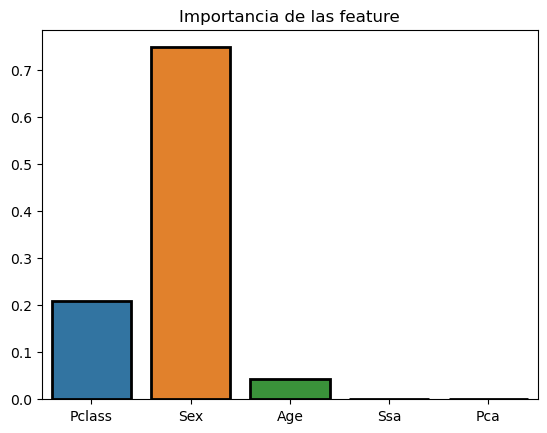

In [40]:
import seaborn as sns

importance = tree.feature_importances_
columns = X.columns
sns.barplot(x= columns, y = importance, edgecolor = "black", linewidth = 2)
plt.title("Importancia de las feature")


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  887 non-null    int64  
 1   Pclass    887 non-null    int64  
 2   Sex       887 non-null    int64  
 3   Age       887 non-null    float64
 4   Ssa       887 non-null    int64  
 5   Pca       887 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 41.7 KB


In [4]:
# https://www.kaggle.com/datasets/elikplim/car-evaluation-data-set

In [20]:
df = pd.read_csv("car_evaluation.csv")
df

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5more,more,med,med,good
1723,low,low,5more,more,med,high,vgood
1724,low,low,5more,more,big,low,unacc
1725,low,low,5more,more,big,med,good


In [21]:
df.columns = ["Price", "Maint", "Doors", "Persons", "lug_boot", "Safety", "Decision"]
df

,Price,Maint,Doors,Persons,lug_boot,Safety,Decision
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5more,more,med,med,good
1723,low,low,5more,more,med,high,vgood
1724,low,low,5more,more,big,low,unacc
1725,low,low,5more,more,big,med,good


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Price     1727 non-null   object
 1   Maint     1727 non-null   object
 2   Doors     1727 non-null   object
 3   Persons   1727 non-null   object
 4   lug_boot  1727 non-null   object
 5   Safety    1727 non-null   object
 6   Decision  1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [23]:
df.isnull().sum()

Price       0
Maint       0
Doors       0
Persons     0
lug_boot    0
Safety      0
Decision    0
dtype: int64

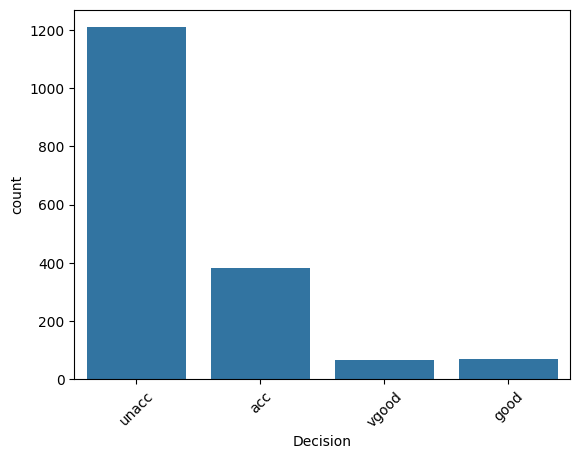

In [24]:
sns.countplot(x="Decision", data=df)
plt.xticks(rotation = 45)
plt.show()

In [25]:
df["Decision"].value_counts()

Decision
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64

In [26]:
x = df.drop("Decision", axis = 1)
y = df.Decision

In [51]:
x

,Price,Maint,Doors,Persons,lug_boot,Safety
0,vhigh,vhigh,2,2,small,med
1,vhigh,vhigh,2,2,small,high
2,vhigh,vhigh,2,2,med,low
3,vhigh,vhigh,2,2,med,med
4,vhigh,vhigh,2,2,med,high
...,...,...,...,...,...,...
1722,low,low,5more,more,med,med
1723,low,low,5more,more,med,high
1724,low,low,5more,more,big,low
1725,low,low,5more,more,big,med


In [28]:
from sklearn.preprocessing import OrdinalEncoder
transfomr = OrdinalEncoder()
x = pd.DataFrame(transfomr.fit_transform(x), columns=x.columns)
x


,Price,Maint,Doors,Persons,lug_boot,Safety
0,3.0,3.0,0.0,0.0,2.0,2.0
1,3.0,3.0,0.0,0.0,2.0,0.0
2,3.0,3.0,0.0,0.0,1.0,1.0
3,3.0,3.0,0.0,0.0,1.0,2.0
4,3.0,3.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...
1722,1.0,1.0,3.0,2.0,1.0,2.0
1723,1.0,1.0,3.0,2.0,1.0,0.0
1724,1.0,1.0,3.0,2.0,0.0,1.0
1725,1.0,1.0,3.0,2.0,0.0,2.0


In [29]:
y

0       unacc
1       unacc
2       unacc
3       unacc
4       unacc
        ...  
1722     good
1723    vgood
1724    unacc
1725     good
1726    vgood
Name: Decision, Length: 1727, dtype: object

In [31]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

Este es un modelo con random forest 

In [34]:
from sklearn.ensemble import RandomForestClassifier
 
randomForest = RandomForestClassifier(n_estimators= 20, random_state= 42)
randomForest.fit(x_train, y_train)
y_predict =randomForest.predict(x_test)
 

In [35]:
from sklearn.metrics import accuracy_score
 
accuracy = accuracy_score(y_test, y_predict)
print("Accuracy : ", accuracy)

Accuracy :  0.9682080924855492


In [36]:
# Verificar la importancia de las caracteristicas
 
feature_importance_df = pd.DataFrame( {"Features": list(x.columns), "importance": randomForest.feature_importances_}).sort_values("importance")
feature_importance_df

,Features,importance
2,Doors,0.062752
4,lug_boot,0.068510
1,Maint,0.172189
0,Price,0.184250
3,Persons,0.224646
5,Safety,0.287653


(array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35]),
 [Text(0.0, 0, '0.00'),
  Text(0.05, 0, '0.05'),
  Text(0.1, 0, '0.10'),
  Text(0.15000000000000002, 0, '0.15'),
  Text(0.2, 0, '0.20'),
  Text(0.25, 0, '0.25'),
  Text(0.30000000000000004, 0, '0.30'),
  Text(0.35000000000000003, 0, '0.35')])

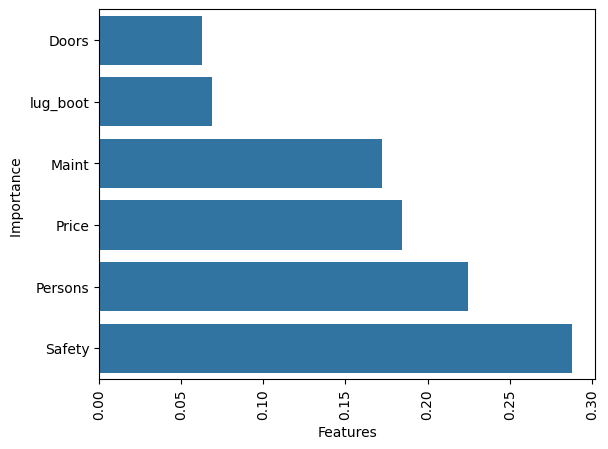

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
 
sns.barplot(y = feature_importance_df.Features , x = feature_importance_df.importance )
plt.xlabel('Features')
plt.ylabel("Importance ")
plt.xticks(rotation = 90 )

In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

         acc       0.91      0.95      0.93        77
        good       0.91      0.67      0.77        15
       unacc       0.99      1.00      0.99       237
       vgood       1.00      0.88      0.94        17

    accuracy                           0.97       346
   macro avg       0.95      0.87      0.91       346
weighted avg       0.97      0.97      0.97       346



In [64]:
tree = DecisionTreeClassifier(max_depth = 2, random_state=42)
tree.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [65]:
y_predict = tree.predict(x_test)
accurracy = accuracy_score(y_test, y_predict)
print("Accuracy : ", accurracy )

Accuracy :  0.7514450867052023


Text(0.5, 1.0, 'Importancia de las feature')

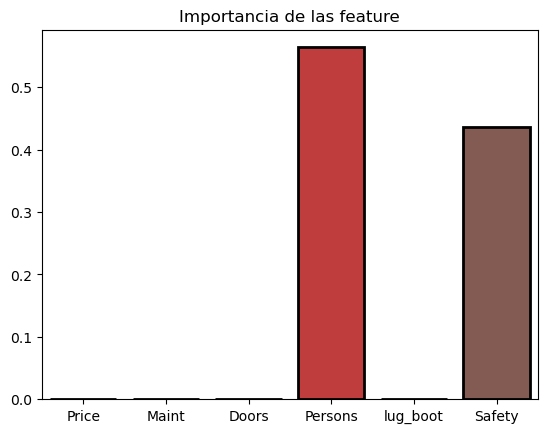

In [66]:
import seaborn as sns

importance = tree.feature_importances_
columns = x.columns
sns.barplot(x= columns, y = importance, edgecolor = "black", linewidth = 2)
plt.title("Importancia de las feature")


In [73]:
from sklearn.metrics import f1_score

score = f1_score(y_test,y_predict, average="micro")
score

0.7514450867052023

Arbol de decisión para regresión 

In [2]:
import seaborn as sns

data = sns.load_dataset("diamonds")
data


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [8]:
data.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [9]:
x = data.drop("price", axis=1)
y = data.price

In [11]:
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
transfomr = OrdinalEncoder()
x = pd.DataFrame(transfomr.fit_transform(x), columns=x.columns)
x


,carat,cut,color,clarity,depth,table,x,y,z
0,3.0,2.0,1.0,3.0,83.0,30.0,20.0,26.0,24.0
1,1.0,3.0,1.0,2.0,66.0,90.0,14.0,12.0,12.0
2,3.0,1.0,1.0,4.0,37.0,115.0,30.0,35.0,12.0
3,9.0,3.0,5.0,5.0,92.0,60.0,45.0,51.0,44.0
4,11.0,1.0,6.0,3.0,101.0,60.0,59.0,63.0,56.0
...,...,...,...,...,...,...,...,...,...
53935,52.0,2.0,0.0,2.0,76.0,50.0,200.0,204.0,131.0
53936,52.0,1.0,0.0,2.0,99.0,30.0,194.0,203.0,142.0
53937,50.0,4.0,0.0,2.0,96.0,80.0,191.0,196.0,137.0
53938,66.0,3.0,4.0,3.0,78.0,60.0,240.0,240.0,155.0


In [3]:
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [18]:
data.shape

(53940, 10)

In [25]:
tree = DecisionTreeClassifier(max_depth = 20, random_state = 42)
tree.fit(x_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [26]:
from sklearn.metrics import r2_score, mean_squared_error

y_predict = tree.predict(x_test)
mse = mean_squared_error(y_test, y_predict)
r2 = r2_score(y_test, y_predict)

print("mse :", mse)
print("rmse : ", mse**(1/2))
print("r2 : ", r2)



mse : 2055698.6431219873
rmse :  1433.7707777472615
r2 :  0.8706849259504579


Text(0.5, 1.0, 'Importancia de las feature')

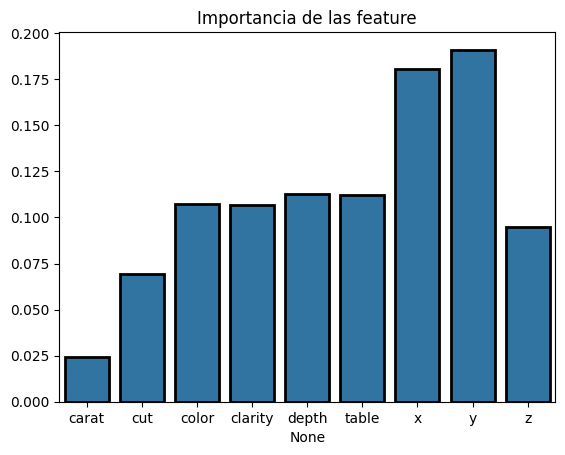

In [27]:
import seaborn as sns

importance = tree.feature_importances_
columns = x.columns
sns.barplot(x= columns, y = importance, edgecolor = "black", linewidth = 2)
plt.title("Importancia de las feature")

Text(0, 0.5, 'Precio predicho')

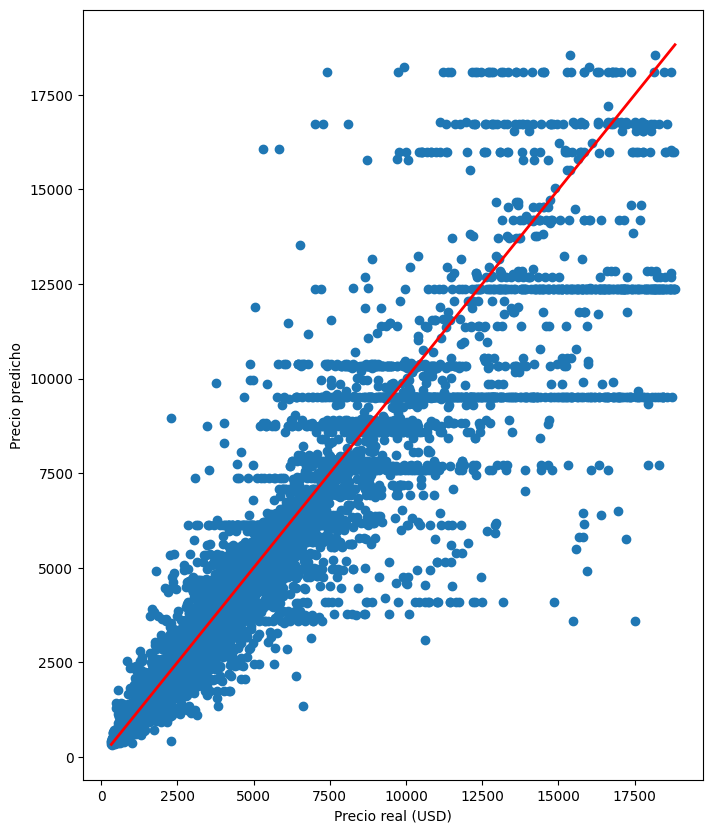

In [29]:
import matplotlib.pyplot as plt 
import numpy as np 

fig, ax = plt.subplots(figsize=(8,10))

ax.scatter(y_test, y_predict)
line = [y_test.min(), y_test.max()]
ax.plot(line,line, color = "red", linewidth=2)

plt.xlabel("Precio real (USD)")
plt.ylabel("Precio predicho")




Mi primer random forest 

In [4]:
df = pd.read_csv("pima-indians-diabetes.csv")
df

,6,148,72,35,0,33.6,0.627,50,1
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0
...,...,...,...,...,...,...,...,...,...
762,10,101,76,48,180,32.9,0.171,63,0
763,2,122,70,27,0,36.8,0.340,27,0
764,5,121,72,23,112,26.2,0.245,30,0
765,1,126,60,0,0,30.1,0.349,47,1


In [31]:
#https://www.kaggle.com/datasets/kumargh/pimaindiansdiabetescsv

In [5]:
df.columns = ['1. Number of times pregnant', '2. Plasma glucose concentration a 2 hours in an oral glucose tolerance test', '3. Diastolic blood pressure (mm Hg)', '4. Triceps skin fold thickness (mm)', '5. 2-Hour serum insulin (mu U/ml)', '6. Body mass index (weight in kg/(height in m)^2)', '7. Diabetes pedigree function', '8. Age (years)', '9. Class variable (0 or 1)']
df

,1. Number of times pregnant,2. Plasma glucose concentration a 2 hours in an oral glucose tolerance test,3. Diastolic blood pressure (mm Hg),4. Triceps skin fold thickness (mm),5. 2-Hour serum insulin (mu U/ml),6. Body mass index (weight in kg/(height in m)^2),7. Diabetes pedigree function,8. Age (years),9. Class variable (0 or 1)
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0
...,...,...,...,...,...,...,...,...,...
762,10,101,76,48,180,32.9,0.171,63,0
763,2,122,70,27,0,36.8,0.340,27,0
764,5,121,72,23,112,26.2,0.245,30,0
765,1,126,60,0,0,30.1,0.349,47,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 767 entries, 0 to 766
Data columns (total 9 columns):
 #   Column                                                                       Non-Null Count  Dtype  
---  ------                                                                       --------------  -----  
 0   1. Number of times pregnant                                                  767 non-null    int64  
 1   2. Plasma glucose concentration a 2 hours in an oral glucose tolerance test  767 non-null    int64  
 2   3. Diastolic blood pressure (mm Hg)                                          767 non-null    int64  
 3   4. Triceps skin fold thickness (mm)                                          767 non-null    int64  
 4   5. 2-Hour serum insulin (mu U/ml)                                            767 non-null    int64  
 5   6. Body mass index (weight in kg/(height in m)^2)                            767 non-null    float64
 6   7. Diabetes pedigree function              

In [7]:
df.isnull().sum()

1. Number of times pregnant                                                    0
2. Plasma glucose concentration a 2 hours in an oral glucose tolerance test    0
3. Diastolic blood pressure (mm Hg)                                            0
4. Triceps skin fold thickness (mm)                                            0
5. 2-Hour serum insulin (mu U/ml)                                              0
6. Body mass index (weight in kg/(height in m)^2)                              0
7. Diabetes pedigree function                                                  0
8. Age (years)                                                                 0
9. Class variable (0 or 1)                                                     0
dtype: int64

En este conjunto de datos hay 8 características  de entrada y 1 característica de salida / destino / target. 

El significado de los nombres de las características es el siguiente:

* Número de embarazos.
* Concentración de glucosa en plasma a 2 horas en una prueba oral de tolerancia a la glucosa.
* Presión arterial diastólica (mm Hg).
* Espesor del pliegue cutáneo del tríceps (mm).
* Insulina sérica de 2 horas (mu U / ml).
* Índice de masa corporal (peso en kg / (altura en m) ^ 2).
* Función del pedigrí de la diabetes.
* Edad (años).
* Variable de clase (0 o 1).

In [8]:
x = df.drop("9. Class variable (0 or 1)", axis=1)
y = df["9. Class variable (0 or 1)"]

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [10]:
from sklearn.ensemble import RandomForestClassifier

randomForest = RandomForestClassifier(n_estimators= 30, random_state= 42)
randomForest.fit(x_train, y_train)
y_predict =randomForest.predict(x_test)

In [11]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_predict)
print("Accuracy : ", accuracy)

Accuracy :  0.8116883116883117


In [13]:
# Verificar la importancia de las caracteristicas 

feature_importance_df = pd.DataFrame( {"Features": list(x.columns), "importance": randomForest.feature_importances_}).sort_values("importance")
feature_importance_df

,Features,importance
3,4. Triceps skin fold thickness (mm),0.064423
4,5. 2-Hour serum insulin (mu U/ml),0.077613
0,1. Number of times pregnant,0.084258
2,3. Diastolic blood pressure (mm Hg),0.089502
6,7. Diabetes pedigree function,0.133618
7,8. Age (years),0.134601
5,6. Body mass index (weight in kg/(height in m)^2),0.171509
1,2. Plasma glucose concentration a 2 hours in a...,0.244476


(array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 ]),
 [Text(0.0, 0, '0.00'),
  Text(0.05, 0, '0.05'),
  Text(0.1, 0, '0.10'),
  Text(0.15000000000000002, 0, '0.15'),
  Text(0.2, 0, '0.20'),
  Text(0.25, 0, '0.25'),
  Text(0.30000000000000004, 0, '0.30')])

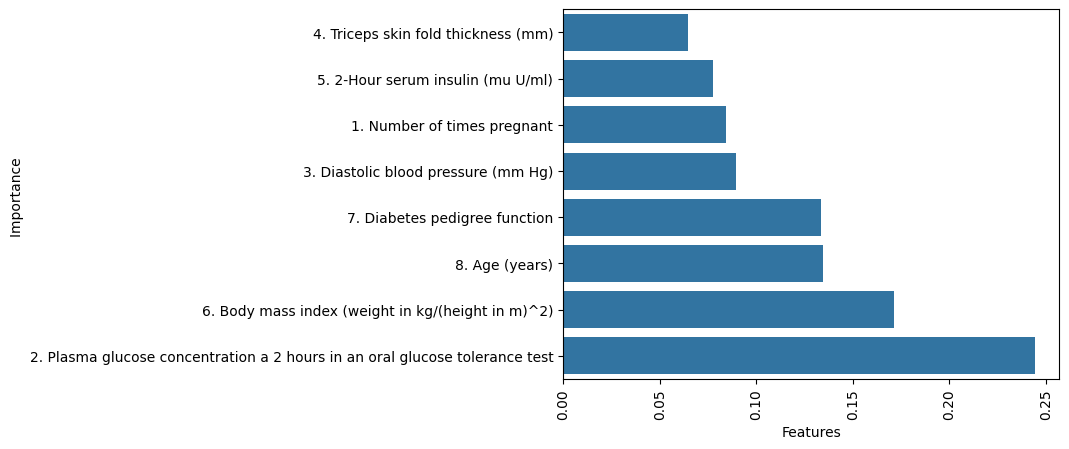

In [18]:
import seaborn as sns 
import matplotlib.pyplot as plt 

sns.barplot(y = feature_importance_df.Features , x = feature_importance_df.importance )
plt.xlabel('Features')
plt.ylabel("Importance ")
plt.xticks(rotation = 90 )




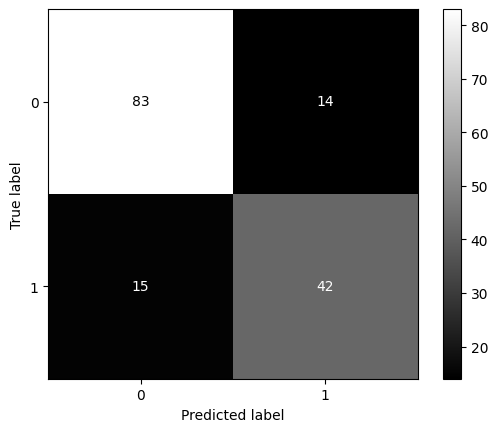

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test,y_predict)
display = ConfusionMatrixDisplay(confusion_matrix= cm )
display.plot(cmap="gray")